# 📈 Linear Regression and Gradient Descent

In this notebook, the student will build an intuition for one of the most fundamental algorithms in machine learning: **Linear Regression**. 

More importantly, the students won't just ask a library to solve it for them. Students will be going to peek under the hood and learn *how* a machine actually learns using optimization algorithms like **Batch Gradient Descent** and **Stochastic Gradient Descent (SGD)**.

### Learning Outcomes :
1. The mathematical foundation of Linear Regression.
2. How the Mean Squared Error (MSE) cost function works.
3. How Gradient Descent minimizes the error.
4. The difference between standard Gradient Descent and Stochastic Gradient Descent.
5. Visualizing the optimization process.
6. Understanding the regularization techniques to prevent overfitting.

In [1]:
# Import our necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display, HTML
%matplotlib widget

# Set random seed for reproducibility
np.random.seed(42)

# Make matplotlib look a bit nicer
plt.style.use('ggplot')

## 1. Linear Regression: The Basics


[Image of linear regression best fit line]


At its core, linear regression is about finding the "line of best fit" through a set of data points. 

If we have a single feature $x$, our hypothesis (the line) is represented by:
$$h_\theta(x) = \theta_0 + \theta_1 x$$

* $\theta_0$ is the **y-intercept** (bias).
* $\theta_1$ is the **slope** (weight).

### The Cost Function
How do we know if our line is good? We measure the error! The standard way to do this in linear regression is the **Mean Squared Error (MSE)** cost function, denoted as $J(\theta)$:

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

Where $m$ is the number of training examples. Our goal in machine learning is simple: **Find the values of $\theta_0$ and $\theta_1$ that make $J(\theta_0, \theta_1)$ as small as possible.**

Let's generate some fake data to play with!

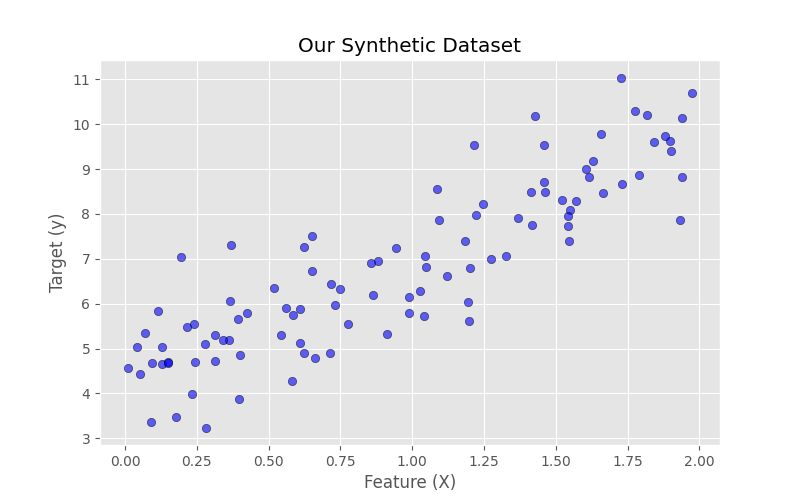

In [2]:
# Generate 100 random data points
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1) # True equation: y = 4 + 3x + noise

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, edgecolors='k')
plt.title("Our Synthetic Dataset")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.show()

## 2. Gradient Descent: Walking Down the Hill


Imagine you are blindfolded at the top of a bowl-shaped mountain, and your goal is to reach the bottom. What do you do? You feel the slope of the ground with your feet and take a step downhill. You repeat this until the ground is flat.

This is exactly what **Gradient Descent** does. It calculates the slope (gradient) of the cost function $J(\theta)$ and takes a step in the opposite direction.

### The Update Rule
For each parameter $\theta_j$, we update it simultaneously using the learning rate $\alpha$ (the size of your step):

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta_0, \theta_1)$$

For our specific MSE cost function, the derivatives are:
* For $\theta_0$: $\frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})$
* For $\theta_1$: $\frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$


C:\Users\kisha\AppData\Local\Temp\ipykernel_15276\2049894772.py:43: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


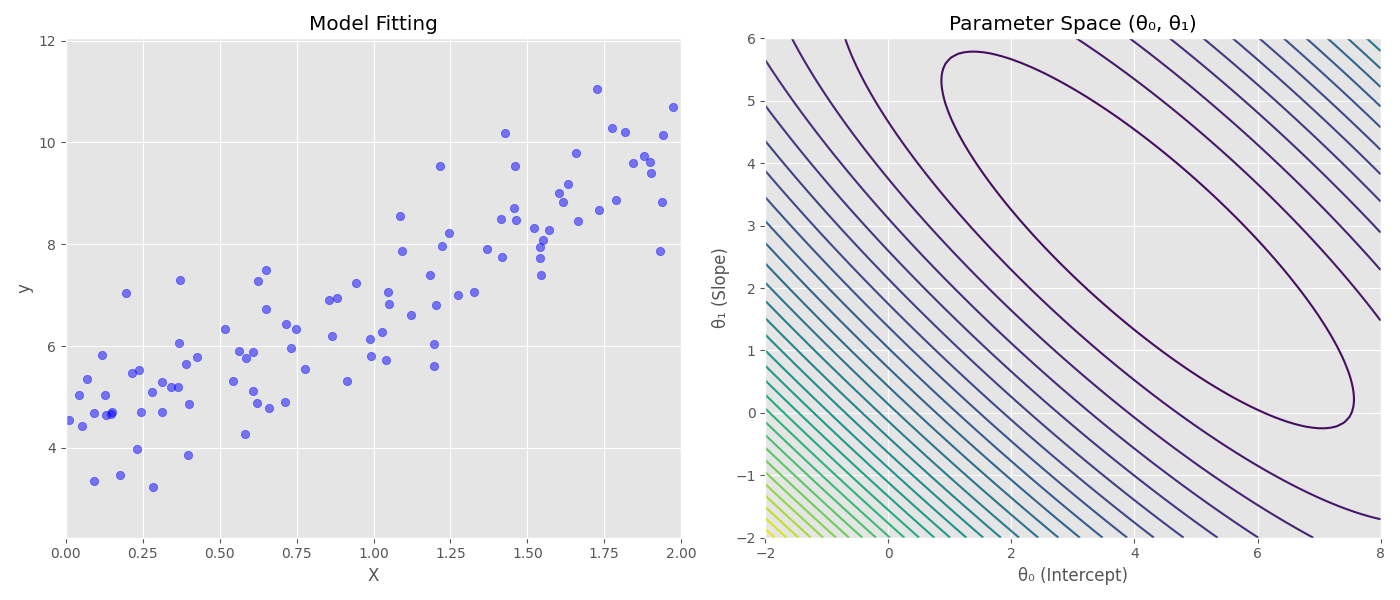

Final parameters found by Gradient Descent:
Intercept = 3.91
Slope     = 3.04
True values were: Intercept = 4.0, Slope = 3.0


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Generate synthetic dataset
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

X_b = np.c_[np.ones((m, 1)), X]

# Gradient Descent Setup
learning_rate = 0.1
n_iterations = 50

theta = np.random.randn(2, 1)
history_gd = [theta.copy()]

def compute_cost(theta):
    return (1/m) * np.sum((X_b.dot(theta) - y) ** 2)

# Run GD and store path
for _ in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - learning_rate * gradients
    history_gd.append(theta.copy())

history_gd = np.array(history_gd)

# Prepare Contour Plot Data
theta0_vals = np.linspace(-2, 8, 100)
theta1_vals = np.linspace(-2, 6, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros_like(T0)

for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        t = np.array([[T0[j, i]], [T1[j, i]]])
        J_vals[j, i] = compute_cost(t)

# Create Side-by-Side Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT: Data space ----
ax1.scatter(X, y, color='blue', alpha=0.5)
ax1.set_xlim(0, 2)
ax1.set_ylim(y.min()-1, y.max()+1)
ax1.set_title("Model Fitting")
ax1.set_xlabel("X")
ax1.set_ylabel("y")

X_line = np.linspace(0, 2, 100).reshape(100, 1)
X_line_b = np.c_[np.ones((100, 1)), X_line]
line, = ax1.plot([], [], color='red', linewidth=2)

# ---- RIGHT: Contour plot ----
contours = ax2.contour(T0, T1, J_vals, levels=30)
ax2.set_title("Parameter Space (θ₀, θ₁)")
ax2.set_xlabel("θ₀ (Intercept)")
ax2.set_ylabel("θ₁ (Slope)")

path_line, = ax2.plot([], [], 'r-o', markersize=4)

# Animation Function
def update(frame):
    theta = history_gd[frame]

    # Update regression line
    y_pred = X_line_b.dot(theta)
    line.set_data(X_line, y_pred)

    # Update contour path
    theta0_path = history_gd[:frame+1, 0, 0]
    theta1_path = history_gd[:frame+1, 1, 0]
    path_line.set_data(theta0_path, theta1_path)

    ax1.set_title(f"Model Fitting (Iteration {frame})")

    return line, path_line

anim = FuncAnimation(
    fig,
    update,
    frames=len(history_gd),
    interval=200,
    blit=True,
    repeat=False
)

plt.tight_layout()
plt.show()

# Final Parameters
final_theta = history_gd[-1]
print(f"Final parameters found by Gradient Descent:")
print(f"Intercept = {final_theta[0][0]:.2f}")
print(f"Slope     = {final_theta[1][0]:.2f}")
print("True values were: Intercept = 4.0, Slope = 3.0")

## 3. Stochastic Gradient Descent (SGD)

Batch Gradient Descent is great, but it has a flaw: it uses the **entire training set** to compute the gradients at every single step. If you have millions of data points, this is incredibly slow.

**Stochastic Gradient Descent (SGD)** fixes this. Instead of looking at all the data, it picks a **single, random data point** at every step and calculates the gradient based only on that one point.

* **Pros:** Much faster. Can escape local minima because it bounces around a bit.
* **Cons:** Because it's "stochastic" (random), it's noisy. It will bounce around the minimum and never settle exactly on the absolute perfect bottom.

Let's visualize the path SGD takes compared to standard Gradient Descent using an interactive chart!

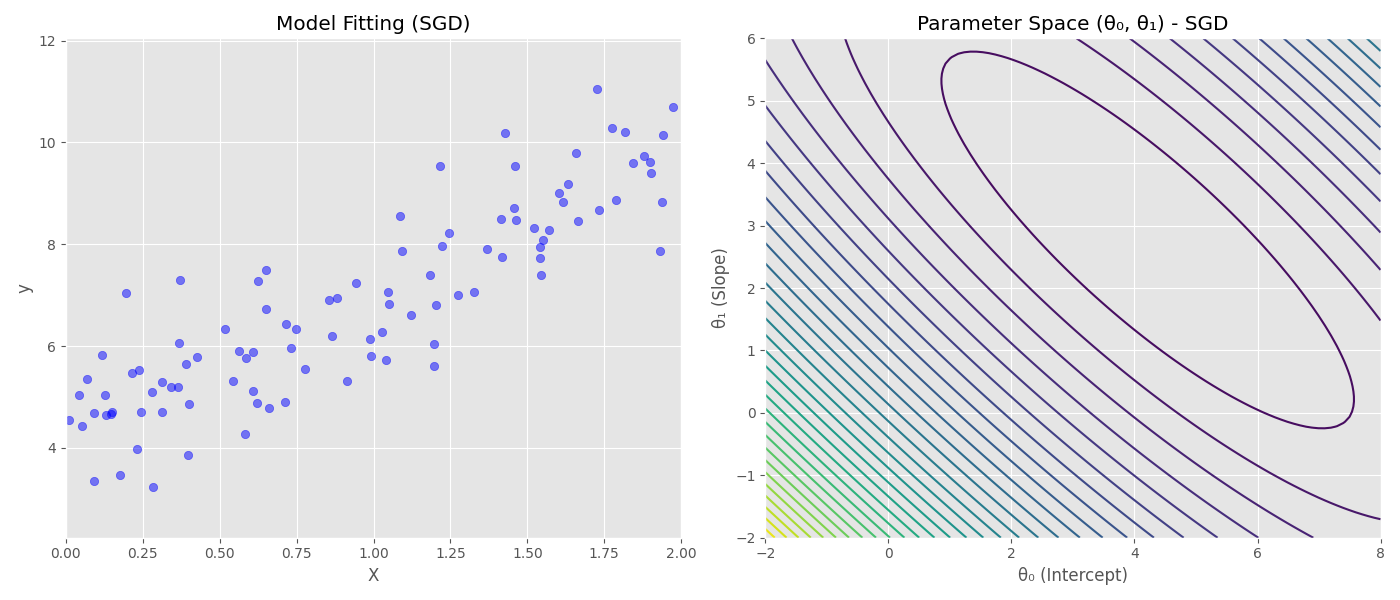

Final parameters found by SGD:
Intercept = 4.37
Slope     = 2.43
True values were: Intercept = 4.0, Slope = 3.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Generate linear dataset
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

X_b = np.c_[np.ones((m, 1)), X]

# SGD Setup
learning_rate = 0.1
n_epochs = 10   # number of full passes over dataset

theta = np.random.randn(2, 1)
history_sgd = [theta.copy()]

def compute_cost(theta):
    return (1/m) * np.sum((X_b.dot(theta) - y) ** 2)

# Run SGD and store path
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        theta = theta - learning_rate * gradients

        history_sgd.append(theta.copy())

history_sgd = np.array(history_sgd)

# Creating the contour plot of loss function in parameter space
theta0_vals = np.linspace(-2, 8, 100)
theta1_vals = np.linspace(-2, 6, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros_like(T0)

for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        t = np.array([[T0[j, i]], [T1[j, i]]])
        J_vals[j, i] = compute_cost(t)

# Create Side-by-Side Figures with animations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT: Data space ----
ax1.scatter(X, y, color='blue', alpha=0.5)
ax1.set_xlim(0, 2)
ax1.set_ylim(y.min()-1, y.max()+1)
ax1.set_title("Model Fitting (SGD)")
ax1.set_xlabel("X")
ax1.set_ylabel("y")

X_line = np.linspace(0, 2, 100).reshape(100, 1)
X_line_b = np.c_[np.ones((100, 1)), X_line]
line, = ax1.plot([], [], color='red', linewidth=2)

# ---- RIGHT: Contour plot ----
contours = ax2.contour(T0, T1, J_vals, levels=30)
ax2.set_title("Parameter Space (θ₀, θ₁) - SGD")
ax2.set_xlabel("θ₀ (Intercept)")
ax2.set_ylabel("θ₁ (Slope)")

path_line, = ax2.plot([], [], 'r-o', markersize=2)

# Animation Function
def update(frame):
    theta = history_sgd[frame]

    # Update regression line
    y_pred = X_line_b.dot(theta)
    line.set_data(X_line, y_pred)

    # Update contour path
    theta0_path = history_sgd[:frame+1, 0, 0]
    theta1_path = history_sgd[:frame+1, 1, 0]
    path_line.set_data(theta0_path, theta1_path)

    ax1.set_title(f"Model Fitting (SGD Step {frame})")

    return line, path_line

anim = FuncAnimation(
    fig,
    update,
    frames=len(history_sgd),
    interval=20,   # faster because many more steps
    blit=True,
    repeat=False
)

plt.tight_layout()
plt.show()

# ----------------------------
# Final Parameters
# ----------------------------
final_theta = history_sgd[-1]
print(f"Final parameters found by SGD:")
print(f"Intercept = {final_theta[0][0]:.2f}")
print(f"Slope     = {final_theta[1][0]:.2f}")
print("True values were: Intercept = 4.0, Slope = 3.0")

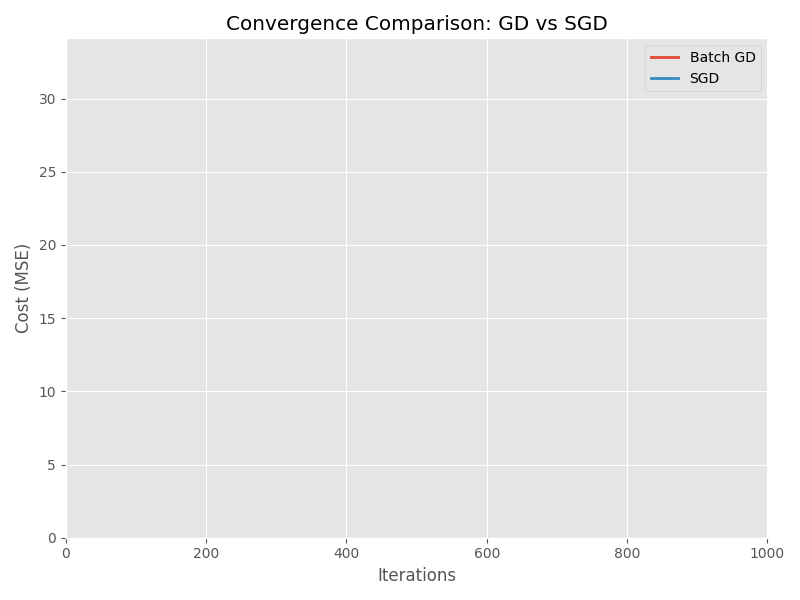

In [ ]:
# Comparing the convergence of loss for GD and SGD based in history (history_gd and history_sgd) with animation

def compute_cost(theta):
    return (1/m) * np.sum((X_b.dot(theta) - y) ** 2)

# Compute costs for each step in history
costs_gd = [compute_cost(theta) for theta in history_gd]
costs_sgd = [compute_cost(theta) for theta in history_sgd]

# Convergence Comparison Animation

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title("Convergence Comparison: GD vs SGD")
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (MSE)")

ax.set_xlim(0, max(len(costs_gd), len(costs_sgd)))
ax.set_ylim(0, max(max(costs_gd), max(costs_sgd)) * 1.1)

line_gd, = ax.plot([], [], label="Batch GD", linewidth=2)
line_sgd, = ax.plot([], [], label="SGD", linewidth=2)

ax.legend()

def update(frame):
    # GD updates
    if frame < len(costs_gd):
        line_gd.set_data(range(frame + 1), costs_gd[:frame + 1])
    else:
        line_gd.set_data(range(len(costs_gd)), costs_gd)

    # SGD updates
    if frame < len(costs_sgd):
        line_sgd.set_data(range(frame + 1), costs_sgd[:frame + 1])
    else:
        line_sgd.set_data(range(len(costs_sgd)), costs_sgd)

    return line_gd, line_sgd

frames = max(len(costs_gd), len(costs_gd)+100)

anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=20,
    blit=True,
    repeat=False
)

plt.tight_layout()
plt.show()

### Understanding the convergence paths
In the graphs shown above, you can interactively zoom in on the paths:
1. Notice how the **Batch Gradient Descent** takes a very smooth, direct path straight to the optimum values (around 4 for intercept, 3 for slope). 
2. Notice how **Stochastic Gradient Descent** bounces around erratically. It gets to the general area of the solution much faster, but zig-zags wildly because each step is based on just a single data point.

> **Challenge for the Reader:** There is a middle ground called **Mini-batch Gradient Descent**, which calculates the error on small, random subsets of data (e.g., 32 points at a time). Try implementing that yourself!

---

## 5. Regularization: Taming the Overfitting Beast



So far, we've fitted a simple straight line. But what if our data is complex and we use a high-degree polynomial to fit it? The model might try *too hard* to hit every single data point, resulting in a wildly fluctuating curve. This is called **Overfitting**. The model learns the noise in the training data, rather than the underlying pattern, and fails completely on new, unseen data.

To fix this, we use **Regularization**. Regularization deliberately constrains (or "regularizes") the model by penalizing large weights. We change our cost function to say: *"Minimize the error, but also keep the weights $\theta$ as small as possible."*

### Ridge Regression (L2 Regularization)
Ridge regression adds a penalty term equal to the square of the magnitude of the coefficients.

$$J(\theta) = \text{MSE}(\theta) + \alpha \frac{1}{2} \sum_{i=1}^{n} \theta_i^2$$

* The hyperparameter $\alpha$ controls how much you want to penalize the weights. If $\alpha = 0$, it's just standard linear regression.
* Ridge shrinks the weights closer to zero, but rarely exactly to zero.

### Lasso Regression (L1 Regularization)
Lasso (Least Absolute Shrinkage and Selection Operator) adds a penalty term equal to the absolute value of the magnitude of coefficients.

$$J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|$$

* **The speciality of Lasso:** Because of how the math works out with absolute values, Lasso tends to push the weights of less important features to **exactly zero**. This means Lasso performs automatic *feature selection*!

---

# 🎯 Regularization in Polynomial Regression (Ridge)

In high-degree polynomial regression, the model can easily **overfit** noisy training data. To combat this, we use Regularization.

### The Objective Function
We minimize the **Ridge objective function**, which balances fitting the data with keeping the model weights small:

$$J(w) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{d} w_j^2$$



---

### What each term means:

* **First term ($MSE$):** Mean Squared Error. This ensures the model actually fits the training data.
* **Second term ($L2$ penalty):** The sum of squared weights. This penalizes large coefficients.
* **$\lambda$ (lambda):** The regularization strength. It is a hyperparameter that controls the balance between the two terms.

---

### What happens as $\lambda$ increases?

As the penalty becomes stricter, the model changes in the following ways:

* **Coefficients shrink** toward zero (but never quite reach it).
* **High-degree terms shrink first**, reducing the "wiggliness" of the line.
* **The curve becomes smoother**, making it less sensitive to noise.
* **Variance decreases** while **Bias increases**.



---

### Key Insight

Regularization acts like a **complexity dial**:

| Lambda Value | Model State | Result |
| :--- | :--- | :--- |
| $\lambda \to 0$ | High Complexity | **Overfitting** (Low bias, High variance) |
| **Medium $\lambda$** | **Optimal Balance** | **Good Generalization** |
| High $\lambda$ | Low Complexity | **Underfitting** (High bias, Low variance) |

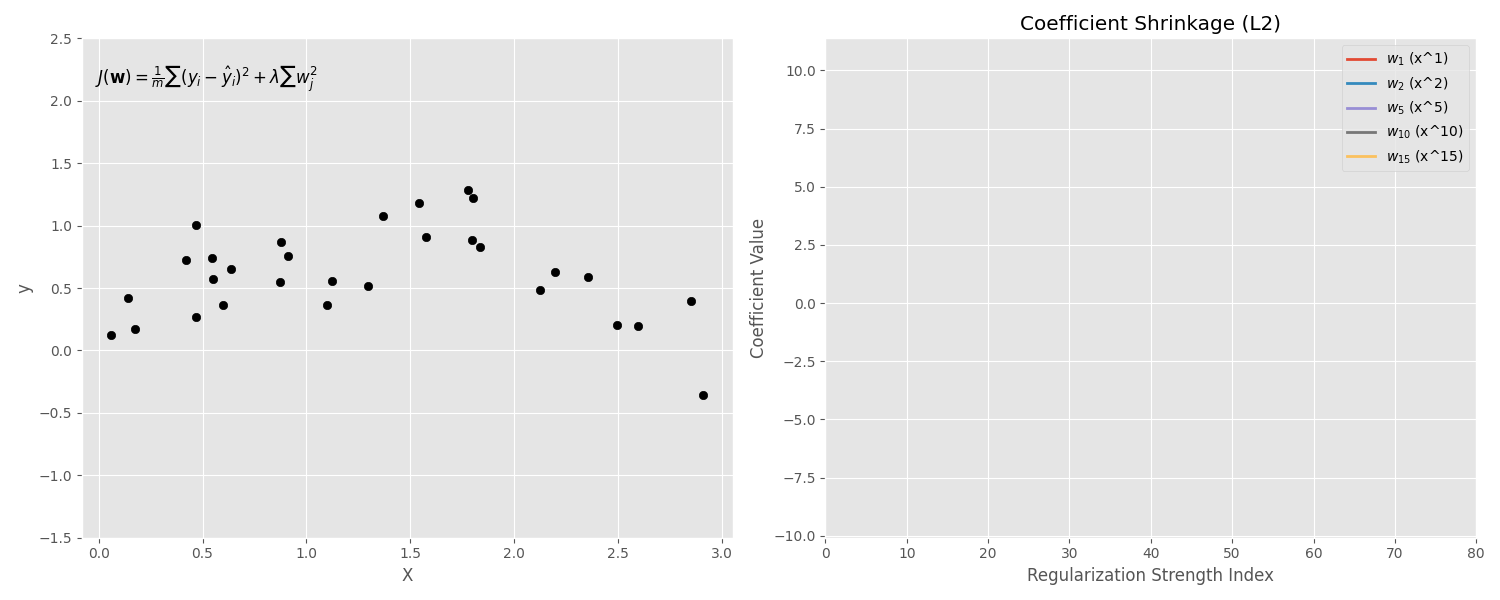

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

# ---------------------------
# 1. Generate Data
# ---------------------------
np.random.seed(42)
m = 30
X = 3 * np.random.rand(m, 1)
y = np.sin(X) + 0.3 * np.random.randn(m, 1)

X_plot = np.linspace(0, 3, 400).reshape(-1, 1)
degree = 15

# ---------------------------
# 2. Model Builder
# ---------------------------
def build_model(alpha):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=alpha)
    )

# ---------------------------
# 3. Compute Regularization Path
# ---------------------------
alphas = np.logspace(-4, 3, 80)

coefs = []
predictions = []

for alpha in alphas:
    model = build_model(alpha)
    model.fit(X, y)
    predictions.append(model.predict(X_plot))
    coefs.append(model.named_steps["ridge"].coef_)

coefs = np.array(coefs)

# ---------------------------
# 4. Create Figure
# ---------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# LEFT: Model Fit
ax1.scatter(X, y, color="black", label="Training Data")
line, = ax1.plot([], [], "r", linewidth=2)
ax1.set_ylim(-1.5, 2.5)
ax1.set_xlabel("X")
ax1.set_ylabel("y")

# Display Ridge equation
eq_text = ax1.text(
    0.02, 0.95,
    r"$J(\mathbf{w}) = \frac{1}{m}\sum (y_i - \hat{y}_i)^2 + \lambda \sum w_j^2$",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment='top'
)

# RIGHT: Coefficient Shrinkage
selected_indices = [0, 1, 4, 9, 14]  # select some degrees to track
coef_lines = []

for idx in selected_indices:
    l, = ax2.plot([], [], linewidth=2, label=f"$w_{{{idx+1}}}$ (x^{idx+1})")
    coef_lines.append(l)

ax2.set_xlim(0, len(alphas))
ax2.set_ylim(coefs.min()*1.1, coefs.max()*1.1)
ax2.set_xlabel("Regularization Strength Index")
ax2.set_ylabel("Coefficient Value")
ax2.set_title("Coefficient Shrinkage (L2)")
ax2.legend()

# ---------------------------
# 5. Animation Function
# ---------------------------
def update(frame):
    # Update model fit
    line.set_data(X_plot, predictions[frame])
    ax1.set_title(f"Ridge Regression (λ = {alphas[frame]:.5f})")

    # Update selected coefficients
    for i, idx in enumerate(selected_indices):
        coef_lines[i].set_data(range(frame+1), coefs[:frame+1, idx])

    return [line] + coef_lines

anim = FuncAnimation(
    fig,
    update,
    frames=len(alphas),
    interval=120,
    blit=True,
    repeat=False
)

plt.tight_layout()
plt.show()

# Ridge vs Lasso: How Do They Differ?

Both Ridge and Lasso add a penalty to the loss function,
but the type of penalty changes the behavior dramatically.

---

## Ridge (L2)

$$
J(\mathbf{w}) =
\frac{1}{m} \sum (y_i - \hat{y}_i)^2
+ \lambda \sum w_j^2
$$

- Shrinks coefficients smoothly
- Keeps all features
- No coefficient becomes exactly zero

---

##  Lasso (L1)

$$
J(\mathbf{w}) =
\frac{1}{m} \sum (y_i - \hat{y}_i)^2
+ \lambda \sum |w_j|
$$

- Some coefficients become exactly zero
- Performs **automatic feature selection**
- Produces sparse models

---

## The below animation shows how the coefficients evolve as we increase λ for both Ridge and Lasso regression.

Left: Ridge regression as λ increases  
Right: Lasso regression as λ increases  

Observe:

- Ridge → smooth shrinkage
- Lasso → sharp transitions and flat segments
- Lasso simplifies the model structure

---

## Key Insight

Ridge controls magnitude.
Lasso controls magnitude *and* selects features.

This difference comes purely from the geometry of the penalty.

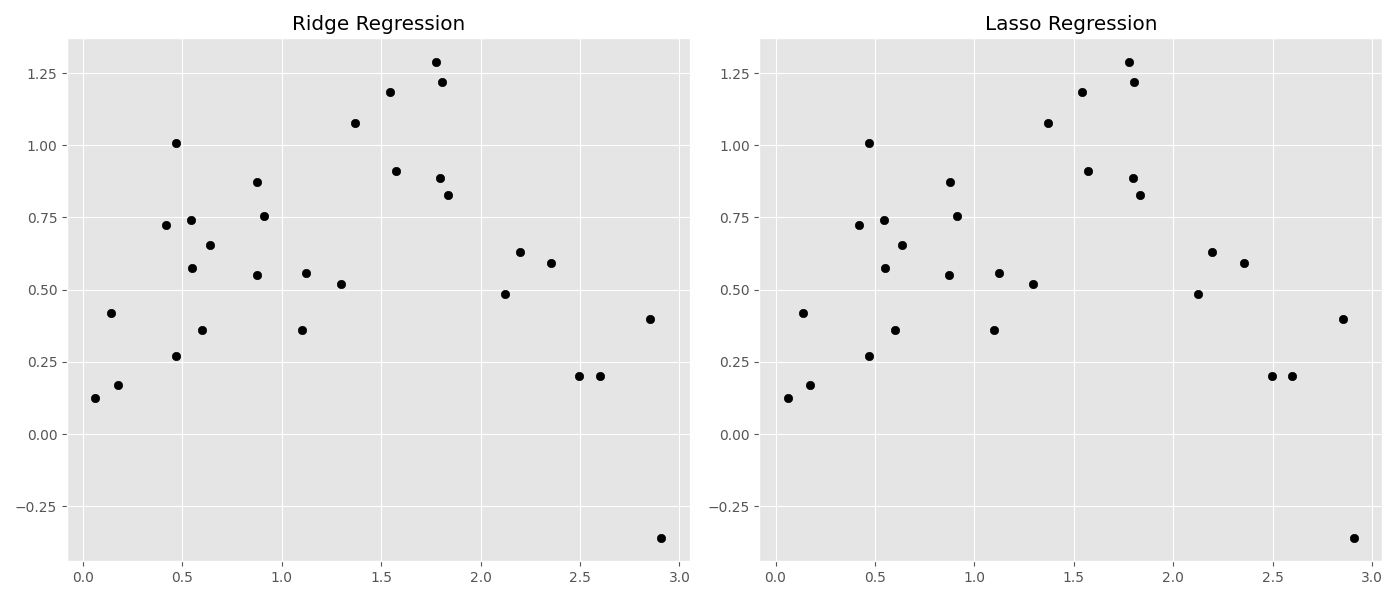

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
import warnings

np.random.seed(42)
m = 30
X = 3 * np.random.rand(m, 1)
y = np.sin(X) + 0.3 * np.random.randn(m, 1)

X_plot = np.linspace(0, 3, 400).reshape(-1, 1)
degree = 15
alphas = np.logspace(-4, 1, 60)

def build_model(model):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        model
    )

ridge_preds = []
lasso_preds = []
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = build_model(Ridge(alpha=alpha))
    ridge.fit(X, y)
    ridge_preds.append(ridge.predict(X_plot))
    ridge_coefs.append(ridge.named_steps["ridge"].coef_)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lasso = build_model(Lasso(alpha=alpha, max_iter=20000))
        lasso.fit(X, y)
        lasso_preds.append(lasso.predict(X_plot))
        lasso_coefs.append(lasso.named_steps["lasso"].coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Ridge plot
axes[0].scatter(X, y, color='black')
ridge_line, = axes[0].plot([], [], 'b', linewidth=2)
axes[0].set_title("Ridge Regression")

# Lasso plot
axes[1].scatter(X, y, color='black')
lasso_line, = axes[1].plot([], [], 'g', linewidth=2)
axes[1].set_title("Lasso Regression")

def update(frame):
    ridge_line.set_data(X_plot, ridge_preds[frame])
    lasso_line.set_data(X_plot, lasso_preds[frame])
    axes[0].set_title(f"Ridge (λ={alphas[frame]:.4f})")
    axes[1].set_title(f"Lasso (λ={alphas[frame]:.4f})")
    return ridge_line, lasso_line

anim = FuncAnimation(fig, update, frames=len(alphas),
                     interval=120, blit=True, repeat=False)

plt.tight_layout()
plt.show()

# Geometric View of Regularization

Regularization can be understood as a **constrained optimization problem**.

Instead of:

$$
\min \text{Loss}
$$

We solve:

$$
\min \text{Loss}
\quad \text{subject to} \quad
\|w\| \leq c
$$

---

## 🔵 Ridge (L2 Constraint)

$$
\|w\|_2^2 = w_1^2 + w_2^2
$$

Constraint region → **circle**

The solution occurs where:
- The elliptical loss contours
- First touch the circular constraint

Because circles are smooth,
solutions rarely lie exactly on axes.

➡ No sparsity.

---

## 🔷 Lasso (L1 Constraint)

$$
\|w\|_1 = |w_1| + |w_2|
$$

Constraint region → **diamond**

The corners lie on coordinate axes.

When loss contours touch a corner:
- One coefficient becomes exactly zero.

➡ Sparsity emerges naturally.

---

## Key Insight

The shape of the constraint determines the behavior:

- Circle → smooth shrinkage
- Diamond → axis-aligned corners → zeros

This geometric view explains everything.

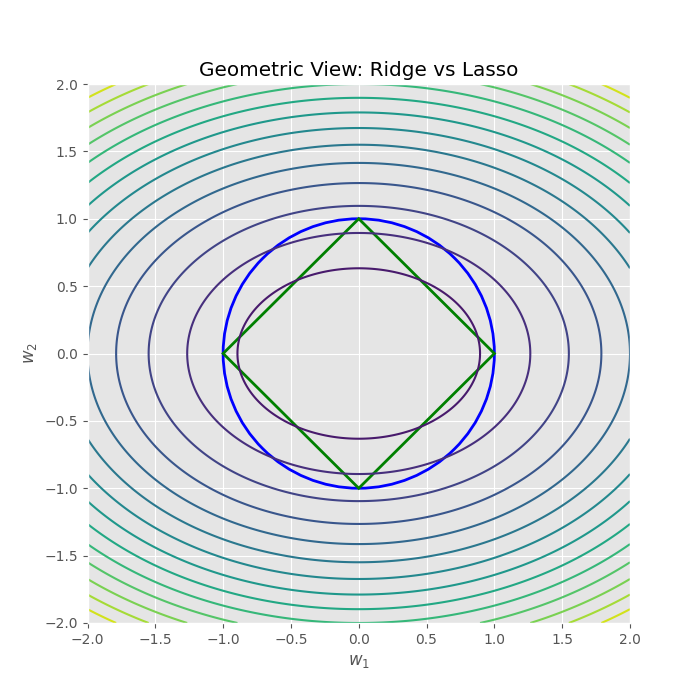

In [16]:
import numpy as np
import matplotlib.pyplot as plt

w1 = np.linspace(-2, 2, 400)
w2 = np.linspace(-2, 2, 400)
W1, W2 = np.meshgrid(w1, w2)

loss = W1**2 + 2*W2**2   # quadratic loss surface

fig, ax = plt.subplots(figsize=(7,7))

# Loss contours
ax.contour(W1, W2, loss, levels=15)

# Ridge constraint (circle)
circle = plt.Circle((0,0), 1, fill=False, color='blue', linewidth=2)
ax.add_artist(circle)

# Lasso constraint (diamond)
diamond = plt.Polygon([[0,1],[1,0],[0,-1],[-1,0]],
                      fill=False, color='green', linewidth=2)
ax.add_artist(diamond)

ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title("Geometric View: Ridge vs Lasso")

plt.show()

# Bias–Variance Tradeoff

As model complexity increases,
training error and test error behave differently.

---

## the Plot below shows how training and test error change as we increase the degree of a polynomial regression model.

Blue curve → Training error  
Red curve → Test error  

As polynomial degree increases:

- Training error always decreases
- Test error forms a U-shaped curve

---

## 📉 Three Cases

### 1️⃣ Underfitting (High Bias)
- Model too simple
- Both errors high

### 2️⃣ Optimal Complexity
- Best generalization
- Minimum test error

### 3️⃣ Overfitting (High Variance)
- Training error very low
- Test error increases

---

## 🎓 Why Regularization Exists

Regularization helps:

- Reduce variance
- Move model away from overfitting region
- Stay near the sweet spot

It does not try to minimize training error —
it tries to minimize **generalization error**.

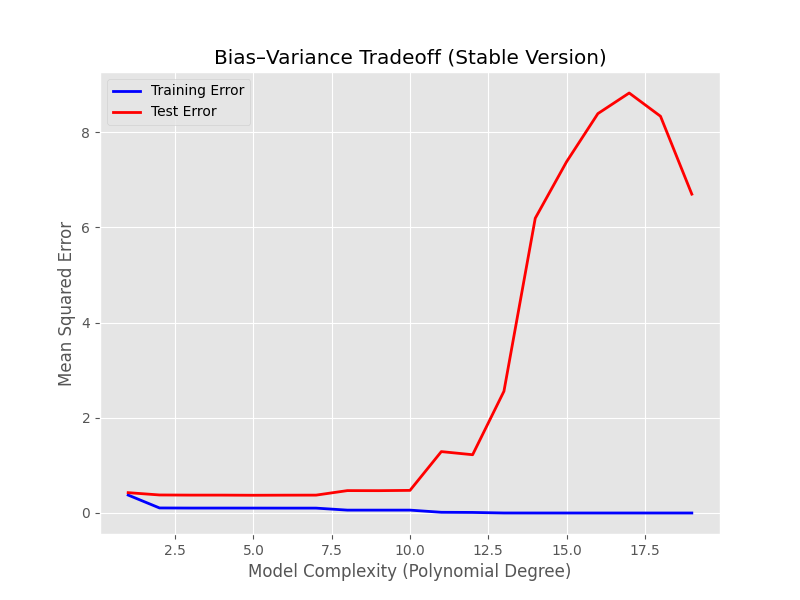

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# 1. Generate Noisy Training Data
m = 15
noise = 0.5

X = np.linspace(0, 3, m).reshape(-1,1)
y = np.sin(X) + noise * np.random.randn(m,1)


# 2. Generate Noisy Test Data
X_test = np.linspace(0,3,200).reshape(-1,1)
y_test = np.sin(X_test) + noise * np.random.randn(200,1)


# 3. Train Models of Increasing Complexity
degrees = range(1, 20)

train_errors = []
test_errors = []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        StandardScaler(),           # ← FIX: scaling prevents explosion
        LinearRegression()
    )

    model.fit(X, y)

    train_errors.append(
        mean_squared_error(y, model.predict(X))
    )

    test_errors.append(
        mean_squared_error(y_test, model.predict(X_test))
    )

# 4. Plot with animation
plt.figure(figsize=(8,6))
plt.plot(degrees, train_errors, 'b', linewidth=2, label="Training Error")
plt.plot(degrees, test_errors, 'r', linewidth=2, label="Test Error")

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias–Variance Tradeoff (Stable Version)")
plt.legend()
plt.show()

# Summary

Regularization solves one core problem:

> High-capacity models overfit noisy data.

We saw:

- Polynomial regression can overfit easily
- Ridge shrinks coefficients smoothly
- Lasso creates sparsity
- Geometry explains why
- Bias–variance tradeoff explains when

---

## Key Takeaways

- λ controls complexity
- Ridge → magnitude control
- Lasso → magnitude + feature selection
- Too little regularization → overfitting
- Too much regularization → underfitting

The goal is not zero training error.

The goal is **best generalization performance**.